In [12]:
import xarray as xr
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from stericheight.data_handler import GEBCO
from stericheight.plotting_fns import PlottingFns
from functions import Functions


pfns = PlottingFns()


In [2]:
analysis=xr.open_mfdataset(glob.glob('../data/EN4/*analysis*.nc'))

/tmp/ipykernel_1460452/2479073870.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  analysis=xr.open_mfdataset(glob.glob('../data/EN4/*analysis*.nc'))


In [4]:
expanded_extent = [132, 156, -68, -62]
en4_expanded = analysis.sel(lon=slice(expanded_extent[0],expanded_extent[1]),lat=slice(expanded_extent[2],expanded_extent[3]))

ds = analysis.sel(lat=slice(-67,-66),lon=slice(139,145))
ds

In [11]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation
elevation = elevation_.sel(latitude = slice(expanded_extent[2], expanded_extent[3]), longitude = slice(expanded_extent[0],expanded_extent[1]))

ValueError: x must be one of None, 'lat', 'lon'. Received 'longitude' instead.

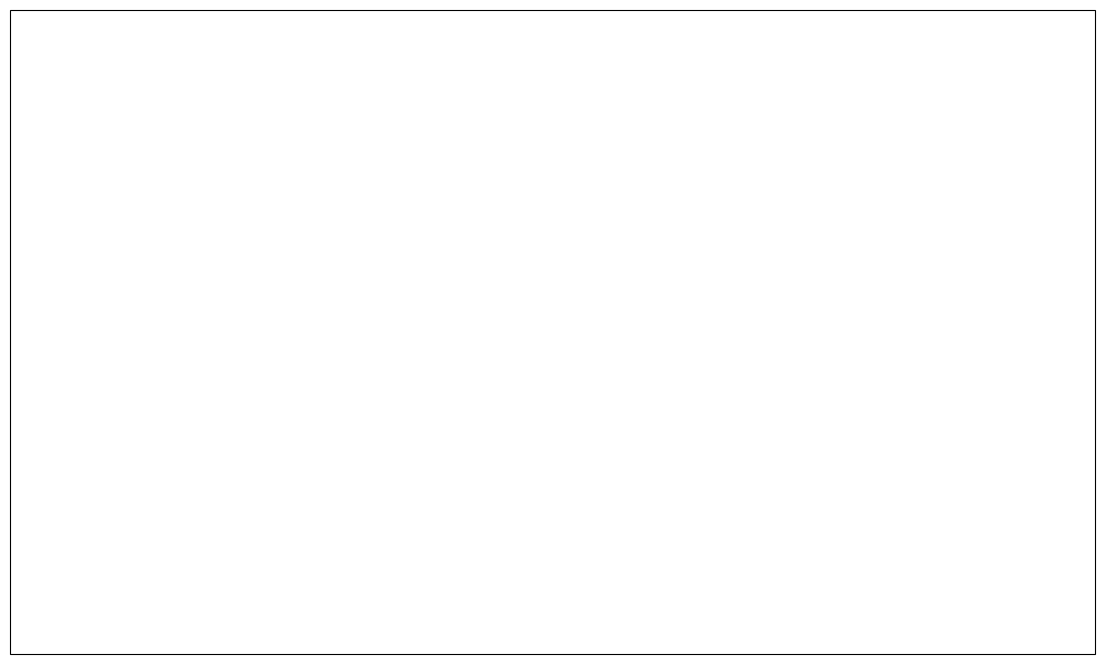

In [13]:
fig,ax=plt.subplots(figsize=(14,9),subplot_kw={'projection':ccrs.Mercator()})
im=pfns.sp(ax,en4_expanded.temperature_observation_weights.sum(['depth']).mean('time'),extent=expanded_extent)
elevation.plot.contour(ax=ax,levels=[-1000],transform=ccrs.PlateCarree())


Text(0, 0.5, 'Pressure')

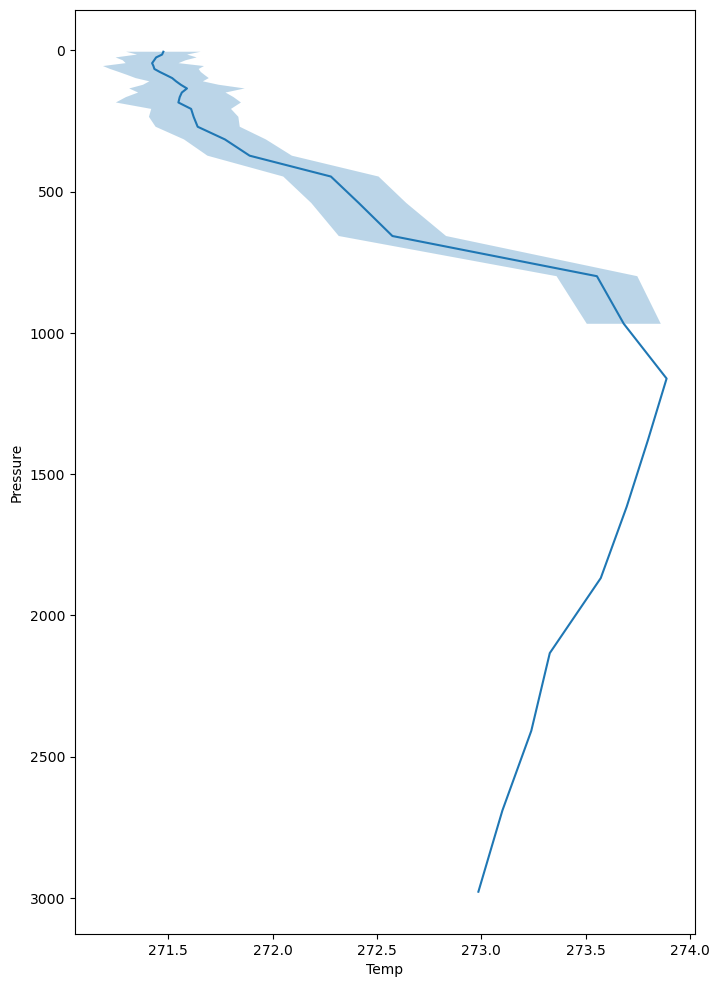

In [10]:

fig, ax = plt.subplots(1,1,figsize=(8,12))


mean_temp = ds.temperature.mean(['time','lat','lon'])
stde_temp = ds.temperature_uncertainty.mean(['time','lat','lon'])



# Mean line
ax.plot(mean_temp, ds.depth)


# Shaded region (choose ONE)
ax.fill_betweenx(ds.depth, mean_temp - stde_temp, mean_temp + stde_temp, alpha=0.3, label='±1 std')

ax.invert_yaxis()
ax.set_xlabel('Temp')
ax.set_ylabel('Pressure')

